In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from os.path import join
import sys
sys.path.append(join(".", ".."))
from utils import *

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

nonseparable problem

In [82]:
trotter_method = "first_order"
data = np.load(f"../resource_analysis_data/fig2_nonseparable_data_{trotter_method}.npz")
error_tols = data["error_tols"]

pauli_basis_trotter_steps = data["pauli_basis_trotter_steps"]
pauli_basis_single_qubit_gates = data["pauli_basis_single_qubit_gates"]
pauli_basis_two_qubit_gates = data["pauli_basis_two_qubit_gates"]
pauli_basis_circ_depth_per_trotter_step = data["pauli_basis_circ_depth"]
pauli_basis_overall_circ_depth = pauli_basis_trotter_steps * pauli_basis_circ_depth_per_trotter_step

one_hot_trotter_steps = data["one_hot_trotter_steps"]
one_hot_single_qubit_gates = data["one_hot_single_qubit_gates"]
one_hot_two_qubit_gates = data["one_hot_two_qubit_gates"]
one_hot_circ_depth_per_trotter_step = data["one_hot_circ_depth"]
one_hot_overall_circ_depth = one_hot_trotter_steps * one_hot_circ_depth_per_trotter_step


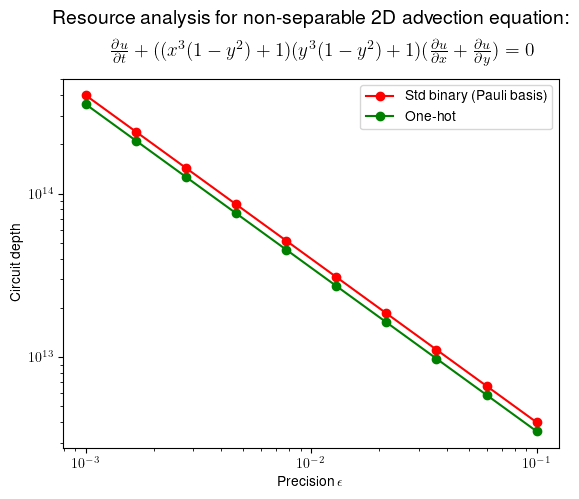

In [83]:
plt.plot(error_tols, pauli_basis_overall_circ_depth, '-o', color="red", label="Std binary (Pauli basis)")
plt.plot(error_tols, one_hot_overall_circ_depth, '-o', color="green", label="One-hot")
plt.title(r"Resource analysis for non-separable 2D advection equation:", y=1.125, size=14)
plt.figtext(x=0.2, y=0.925, s=r"$\frac{\partial u}{\partial t}+((x^3(1-y^2)+1)(y^3(1-y^2)+1)(\frac{\partial u}{\partial x} + \frac{\partial u}{\partial y}) = 0$", size=14)
plt.ylabel("Circuit depth")
plt.xlabel(rf"Precision $\epsilon$")
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.savefig(join("..", "..", "figures", "Fig_2_nonseparable.pdf"), bbox_inches='tight')
plt.show()

nonlinear problem

In [36]:
trotter_method = "first_order"
data = np.load(f"../resource_analysis_data/nonlinear_data_{trotter_method}.npz")
N_vals = data["N_vals"]

pauli_basis_trotter_steps = data["pauli_basis_trotter_steps"]
pauli_basis_single_qubit_gates = data["pauli_basis_single_qubit_gates"]
pauli_basis_two_qubit_gates = data["pauli_basis_two_qubit_gates"]
pauli_basis_gate_count = pauli_basis_trotter_steps * (pauli_basis_single_qubit_gates + pauli_basis_two_qubit_gates)
pauli_basis_circ_depth_per_trotter_step = data["pauli_basis_circ_depth"]
pauli_basis_circ_depth = pauli_basis_trotter_steps * pauli_basis_circ_depth_per_trotter_step

one_hot_trotter_steps = data["one_hot_trotter_steps"]
one_hot_single_qubit_gates = data["one_hot_single_qubit_gates"]
one_hot_two_qubit_gates = data["one_hot_two_qubit_gates"]
one_hot_gate_count = one_hot_trotter_steps * (one_hot_single_qubit_gates + one_hot_two_qubit_gates)
one_hot_circ_depth_per_trotter_step = data["one_hot_circ_depth"]
one_hot_circ_depth = one_hot_trotter_steps * one_hot_circ_depth_per_trotter_step


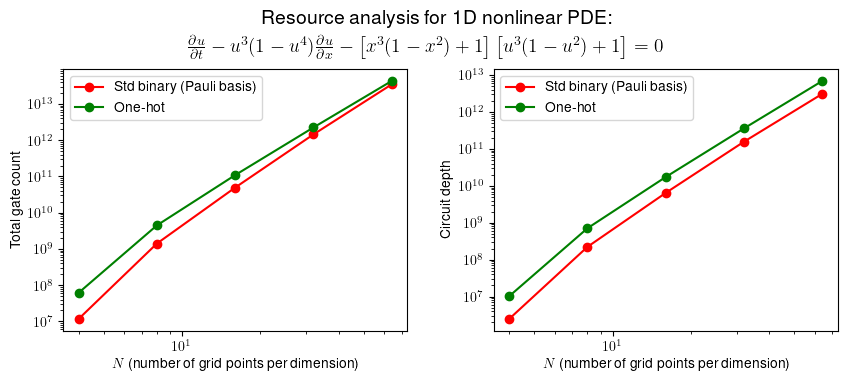

In [42]:
fig = plt.figure(figsize=(10,3.4))
gs = fig.add_gridspec(1, 2, wspace=0.25)
axs = gs.subplots()

fig.suptitle(r"Resource analysis for 1D nonlinear PDE:", y=1.055, size=14)
plt.figtext(x=0.25, y=0.93, s=r"$\frac{\partial u}{\partial t} - u^3 (1-u^4)\frac{\partial u}{\partial x} - \left[x^3(1-x^2)+1\right]\left[u^3(1-u^2)+1\right]=0$", size=14)

axs[0].plot(N_vals, pauli_basis_gate_count, '-o', color="red", label="Std binary (Pauli basis)")
axs[0].plot(N_vals, one_hot_gate_count, '-o', color="green", label="One-hot")
axs[0].set_ylabel("Total gate count")
axs[0].set_xlabel(rf"$N$ (number of grid points per dimension)")
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[0].legend()


axs[1].plot(N_vals, pauli_basis_circ_depth, '-o', color="red", label="Std binary (Pauli basis)")
axs[1].plot(N_vals, one_hot_circ_depth, '-o', color="green", label="One-hot")
axs[1].set_ylabel("Circuit depth")
axs[1].set_xlabel(rf"$N$ (number of grid points per dimension)")
axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].legend()
plt.savefig(join("..", "..", "figures", "Fig_5.pdf"), bbox_inches='tight')
plt.show()